In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
dataset = pd.read_excel("Rainfall data 1.xlsx")
dataset

,Rainfall,Relative Humidity,Solar Radiation,Temp Max,Temp Min,Wind Speed
0,0.0,82,4.3,22.6,13.1,3
1,0.0,78,4.3,24.9,13.0,4
2,37.6,86,0.9,20.8,16.1,8
3,0.2,84,3.1,20.9,13.7,7
4,0.0,81,6.5,23.4,10.5,6
...,...,...,...,...,...,...
7209,0.0,62,7.8,24.0,8.9,6
7210,0.0,62,7.8,24.8,9.4,6
7211,0.0,62,7.8,25.5,10.0,5
7212,0.0,62,7.8,25.6,9.6,6


In [3]:
dataset.isnull().sum()

Rainfall              0
Relative Humidity     0
Solar Radiation       0
Temp Max             12
Temp Min              3
Wind Speed            0
dtype: int64

In [4]:
dataset['Temp Max'].fillna(dataset['Temp Max'].mean(), inplace= True)
dataset['Temp Min'].fillna(dataset['Temp Min'].mean(), inplace= True)

In [5]:
dataset.isnull().sum()

Rainfall             0
Relative Humidity    0
Solar Radiation      0
Temp Max             0
Temp Min             0
Wind Speed           0
dtype: int64

In [6]:
count = 0
for i in dataset['Rainfall']:
    if i == 0:
        count = count + 1

count

5710

In [7]:
rainfall = dataset.pop('Rainfall')
dataset.insert(5, value=rainfall, column='Rainfall')
dataset.head()

,Relative Humidity,Solar Radiation,Temp Max,Temp Min,Wind Speed,Rainfall
0,82,4.3,22.6,13.1,3,0.0
1,78,4.3,24.9,13.0,4,0.0
2,86,0.9,20.8,16.1,8,37.6
3,84,3.1,20.9,13.7,7,0.2
4,81,6.5,23.4,10.5,6,0.0


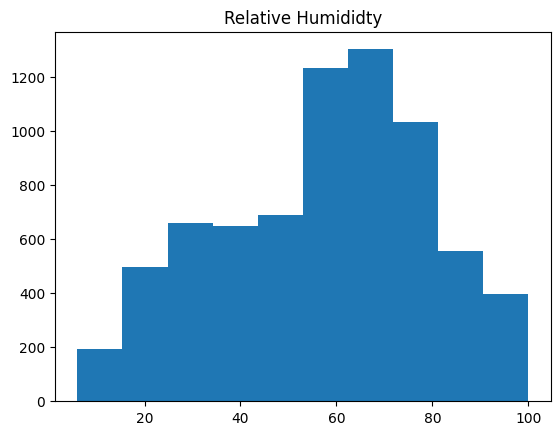

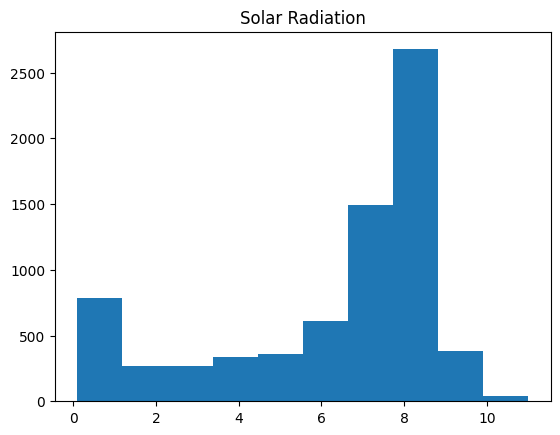

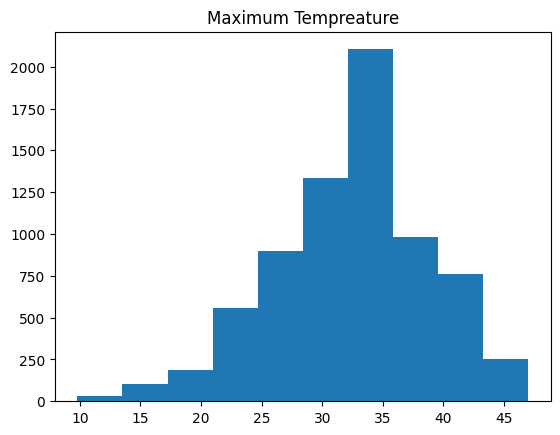

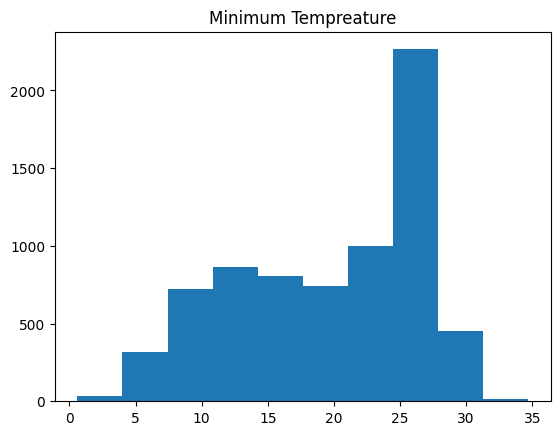

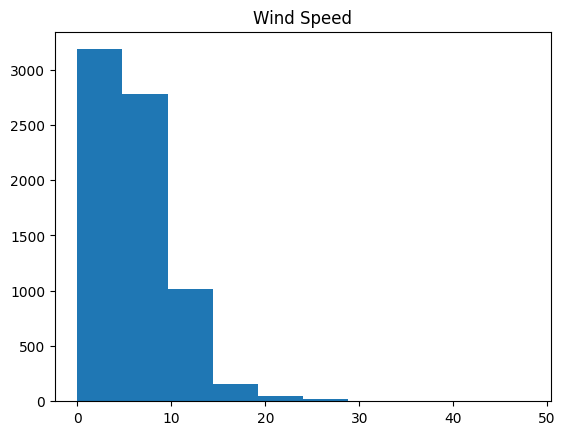

In [8]:
plt.hist(dataset['Relative Humidity'])
plt.title("Relative Humididty")
plt.show()

plt.hist(dataset["Solar Radiation"])
plt.title("Solar Radiation")
plt.show()

plt.hist(dataset['Temp Max'])
plt.title("Maximum Tempreature")
plt.show()

plt.hist(dataset['Temp Min'])
plt.title("Minimum Tempreature")
plt.show()

plt.hist(dataset['Wind Speed'])
plt.title("Wind Speed")
plt.show()

In [9]:
dataset.corr()

,Relative Humidity,Solar Radiation,Temp Max,Temp Min,Wind Speed,Rainfall
Relative Humidity,1.000000,-0.203967,-0.123639,0.237827,0.041754,0.179052
Solar Radiation,-0.203967,1.000000,0.229162,-0.018245,0.086655,-0.179546
Temp Max,-0.123639,0.229162,1.000000,0.769073,0.178984,-0.051919
Temp Min,0.237827,-0.018245,0.769073,1.000000,0.291617,0.146411
Wind Speed,0.041754,0.086655,0.178984,0.291617,1.000000,0.067455
Rainfall,0.179052,-0.179546,-0.051919,0.146411,0.067455,1.000000


In [10]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_train

array([[ 0.49675454,  0.60519767, -1.04877442, -1.46199309, -0.77585511],
       [-0.98478059,  0.93664734, -0.04024642, -0.3145321 , -0.77585511],
       [-1.86444207,  0.56836993,  0.08581958, -0.32887536,  0.99549218],
       ...,
       [-0.52180086, -0.02087395, -1.61607142, -1.36159025, -1.28195434],
       [ 1.05233022, -1.3835004 , -0.16631242,  0.89030193, -0.01670627],
       [ 0.58935049, -0.6837733 ,  0.33795157,  1.04807782, -0.77585511]])

In [13]:
y_train

array([ 0. ,  0. ,  0. , ...,  0. , 12.2,  6.1])

In [14]:
from sklearn.linear_model import LinearRegression
regressor1 =LinearRegression()
regressor1.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred1 = regressor1.predict(X_test)

In [16]:
error = []
r2_list = []

In [17]:
error.append(round(mean_squared_error(y_test, y_pred1), 2))
r2_list.append(round(r2_score(y_test, y_pred1), 2))

In [18]:
from sklearn.svm import SVR
regressor2 = SVR()
regressor2.fit(X_train, y_train)

SVR()

In [19]:
y_pred2 = regressor2.predict(X_test)

In [20]:
error.append(round(mean_squared_error(y_test, y_pred2), 2))
r2_list.append(round(r2_score(y_test, y_pred2), 2))

In [21]:
from sklearn.ensemble import RandomForestRegressor
regressor3 = RandomForestRegressor(n_estimators=100, random_state=0)
regressor3.fit(X_train,y_train)

RandomForestRegressor(random_state=0)

In [22]:
y_pred3 = regressor3.predict(X_test)

In [23]:
error.append(round(mean_squared_error(y_test, y_pred3), 2))
r2_list.append(round(r2_score(y_test, y_pred3), 2))

In [24]:
error

[1405.46, 119.51, 117.25]

In [25]:
r2_list

[-11.29, -0.04, -0.03]

In [26]:
pred_dataset = pd.concat([pd.Series(y_test), pd.Series(y_pred3)], axis= 1)
pred_dataset

,0,1
0,0.0,1.378
1,0.0,1.114
2,0.0,0.282
3,0.0,1.202
4,0.0,1.144
...,...,...
1438,5.6,1.052
1439,2.6,1.378
1440,0.0,1.378
1441,0.0,1.378


<Axes: >

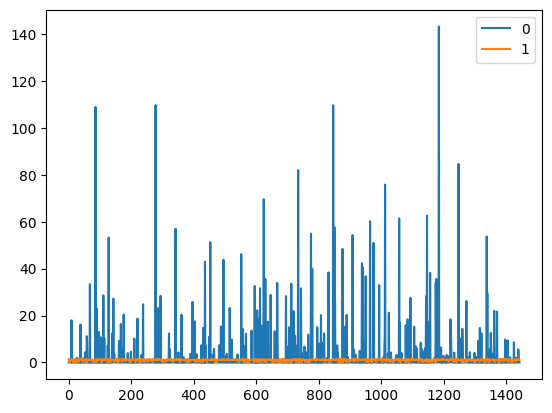

In [27]:
pred_dataset.plot()